# Time Series Modeling with Satellite Data #

This notebook will explore the modeling and predicting the satellite data we've been exploring and cleaning with ARIMA and neural networks.

In [1]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

import warnings
warnings.filterwarnings("ignore")

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

## Satellite dataset ##

In [2]:
sat_folder_addr = "./satellite_data_csv/"
sat_csv_filenames = ["Filled_Station1_Satellite.csv",
                 "Filled_Station2_Satellite.csv",
                 "Filled_Station3_Satellite.csv",
                 "Filled_Station4_Satellite.csv",
                 "Filled_Station5_Satellite.csv",
                 "Filled_Station6_Satellite.csv",]

sat_df_list = []
for filename in sat_csv_filenames:
    sat_df = pd.read_csv(sat_folder_addr + filename, index_col='Date', parse_dates=True)
    sat_df_list.append(sat_df)

In [18]:
sat_df_list[0].head()

,soil_moisture,distance
Date,,
2017-03-18,0.224324,NaN
2017-03-19,0.191104,12.266494
2017-03-20,0.210310,12.266494
2017-03-21,0.168200,12.266494
2017-03-22,0.167357,NaN


In [82]:
# Code generated from ChatGPT
from matplotlib.dates import DateFormatter
from matplotlib.ticker import MultipleLocator

def plot_dataframes(df_list, small_df=False):
    num_plots = len(df_list)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    for r in range(2):
        for c in range(3):
            i = r * 3 + c
            dates = [dt.date() for dt in df_list[i].index.tolist()]
            
            axes[r, c].plot(df_list[i]['soil_moisture'])
            axes[r, c].set_title(f'Station {i+1} for {dates[0]} to {dates[-1]}')
            
            if small_df:
                date_format = DateFormatter('%m-%d')
                axes[r, c].xaxis.set_major_formatter(date_format)
                axes[r, c].xaxis.set_major_locator(MultipleLocator(7))

    plt.tight_layout()
    plt.show()

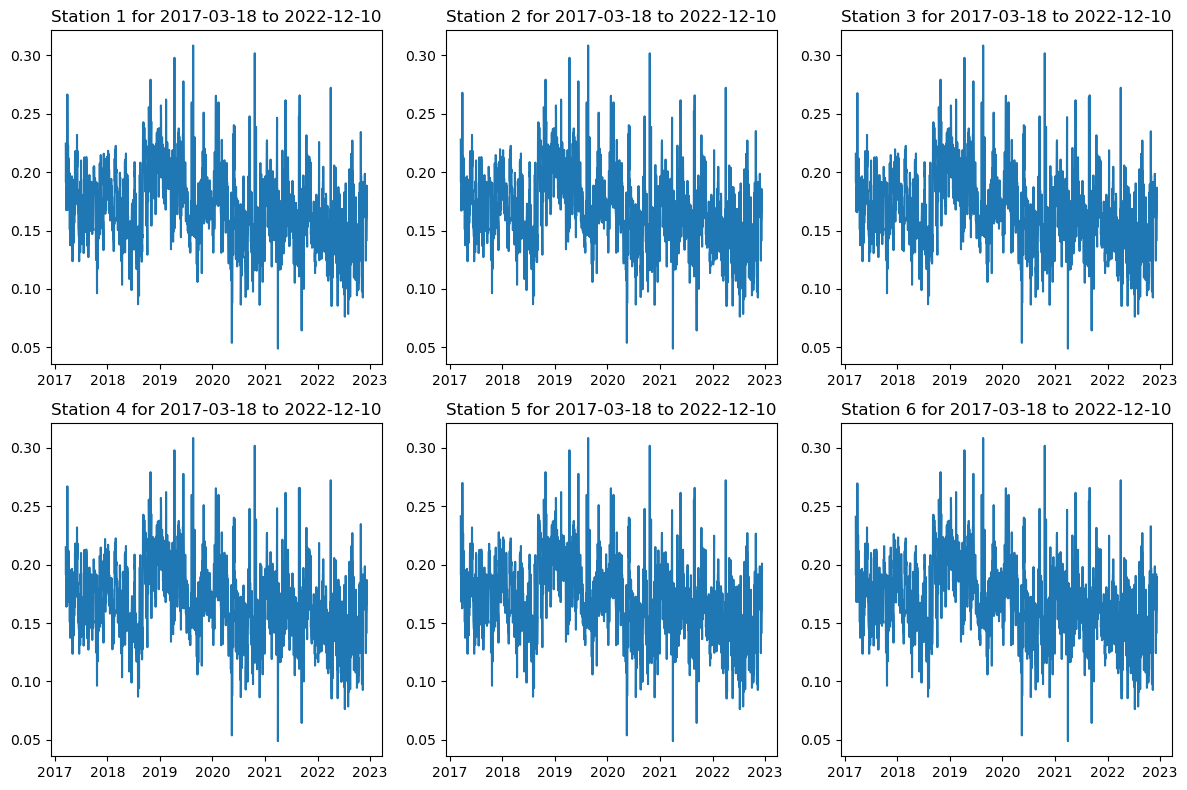

In [83]:
plot_dataframes(sat_df_list)

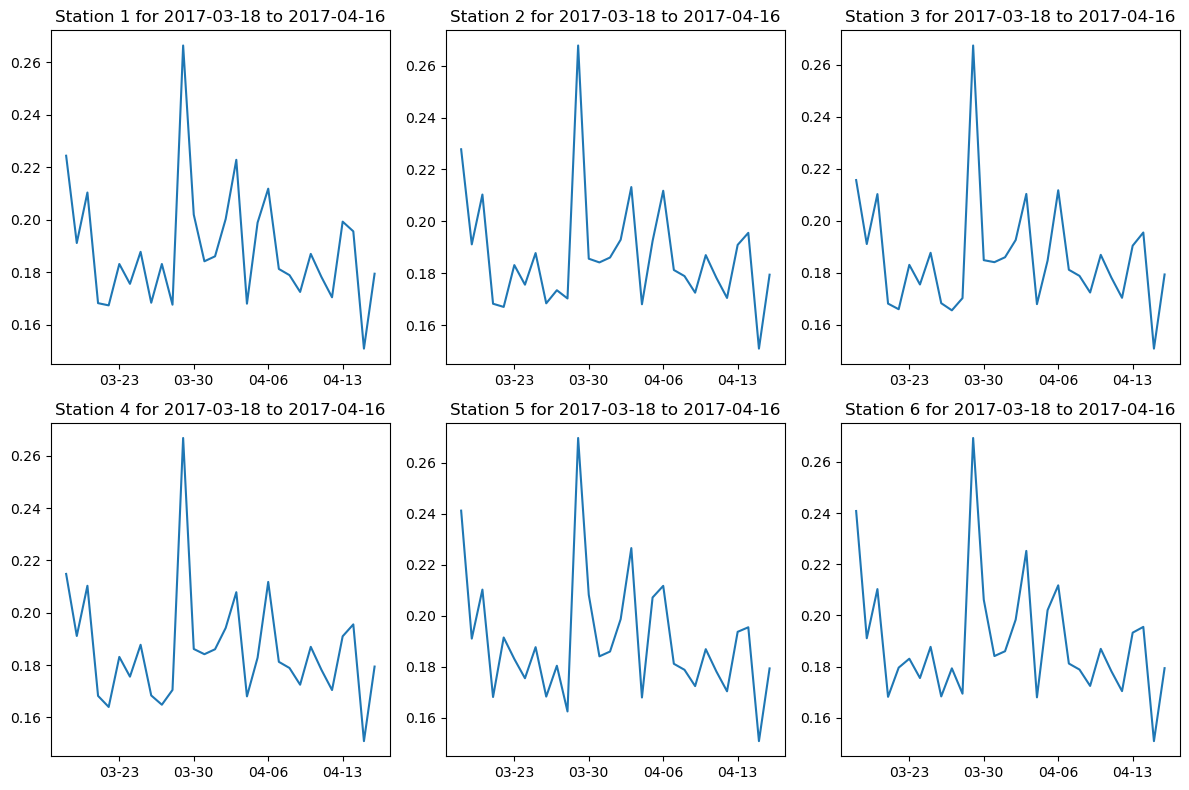

In [84]:
small_sat_df_list = [sat_df[:30] for sat_df in sat_df_list]
plot_dataframes(small_sat_df_list, small_df=True)

### Inspect and cleanup ###

In [85]:
for i, df in enumerate(sat_df_list):
    print("Station", i + 1)
    print("soil_moisture null count:", df['soil_moisture'].isnull().sum())
    print(df['soil_moisture'].describe().transpose(), "\n")

Station 1
soil_moisture null count: 0
count    2094.000000
mean        0.166726
std         0.031620
min         0.049016
25%         0.146290
50%         0.165498
75%         0.186577
max         0.308191
Name: soil_moisture, dtype: float64 

Station 2
soil_moisture null count: 0
count    2094.000000
mean        0.165812
std         0.031762
min         0.049016
25%         0.145028
50%         0.164447
75%         0.186033
max         0.308191
Name: soil_moisture, dtype: float64 

Station 3
soil_moisture null count: 0
count    2094.000000
mean        0.165553
std         0.031841
min         0.049016
25%         0.144436
50%         0.164115
75%         0.185901
max         0.308191
Name: soil_moisture, dtype: float64 

Station 4
soil_moisture null count: 0
count    2094.000000
mean        0.165345
std         0.031983
min         0.049016
25%         0.144276
50%         0.163866
75%         0.185644
max         0.308191
Name: soil_moisture, dtype: float64 

Station 5
soil_moisture 

## Download previous soil moisture datasets ##

In [86]:
# Code taken from notebook/Soil-RNN.ipynb
sm_stat_folder_addr = "../datasets/Simulate_Cleaned_Merged/"
sm_stat_csv_filenames = ["SM_1.dat",
                         "SM_2.dat",
                         "SM_3.dat",
                         "SM_4.dat",
                         "SM_5.dat",
                         "SM_6.dat"]

sm_stat_df_list = []
for filename in sm_stat_csv_filenames:
    sm_sat_df = pd.read_csv(sm_stat_folder_addr + filename, sep=",", parse_dates=["Date"], index_col="Date")
    
    # pandas remove spaces in the column names
    sm_sat_df.columns = sm_sat_df.columns.str.replace(' ','')
    sm_sat_df['SWC_5'] = sm_sat_df['SWC_5'].astype(float)
    sm_sat_df['SWC_10'] = sm_sat_df['SWC_10'].astype(float)
    sm_sat_df['SWC_20'] = sm_sat_df['SWC_20'].astype(float)
    sm_sat_df['SWC_50'] = sm_sat_df['SWC_50'].astype(float)

    sm_sat_df['T_5'] = sm_sat_df['T_5'].astype(float)
    sm_sat_df['T_10'] = sm_sat_df['T_10'].astype(float)
    sm_sat_df['T_20'] = sm_sat_df['T_20'].astype(float)
    sm_sat_df['T_50'] = sm_sat_df['T_50'].astype(float)

    sm_sat_df['Ppt'] = sm_sat_df['Ppt'].astype(float)
    
    # Take the average over the whole day
    sm_sat_df = sm_sat_df.groupby(pd.Grouper(freq='D')).mean()
    
    sm_sat_df = sm_sat_df.rename_axis('Date')
    
    sm_stat_df_list.append(sm_sat_df)

In [87]:
sm_stat_df_list[0].head()

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Flag
Date,,,,,,,,,,
2015-01-01,0.031250,0.141708,0.177792,0.148000,0.151542,3.422083,4.553750,5.600000,10.050833,66.750000
2015-01-02,0.263333,0.159292,0.180583,0.148000,0.151000,3.922500,4.823750,5.652500,9.451667,0.416667
2015-01-03,0.031667,0.179750,0.211167,0.167042,0.150750,6.872917,7.000000,7.105417,9.265000,0.250000
2015-01-04,0.000000,0.164708,0.204833,0.172792,0.151000,5.655417,6.817500,7.554167,9.875000,0.000000
2015-01-05,0.000000,0.152667,0.199292,0.169167,0.150958,4.699167,5.675417,6.430000,9.552083,512.000000


## Check if satellite data matches original data ##

In [129]:
def compare_data(start_date, end_date, range_year=True):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    for r in range(2):
        for c in range(3):
            i = r * 3 + c
            axes[r, c].plot(sat_df_list[i].loc[start_date:end_date]['soil_moisture'])
            axes[r, c].plot(sm_stat_df_list[i].loc[start_date:end_date]['SWC_5'])
            axes[r, c].set_title(f'Station {i+1} for {start_date} to {end_date}')
            
            if range_year:
                date_format = DateFormatter('%b')
                axes[r, c].xaxis.set_major_formatter(date_format)
                axes[r, c].xaxis.set_major_locator(MultipleLocator(30))
                axes[r, c].tick_params(axis='x', rotation=315)
            else:
                date_format = DateFormatter('%m-%d')
                axes[r, c].xaxis.set_major_formatter(date_format)
                axes[r, c].xaxis.set_major_locator(MultipleLocator(7))
                axes[r, c].tick_params(axis='x', rotation=315)

    plt.tight_layout()
    plt.show()

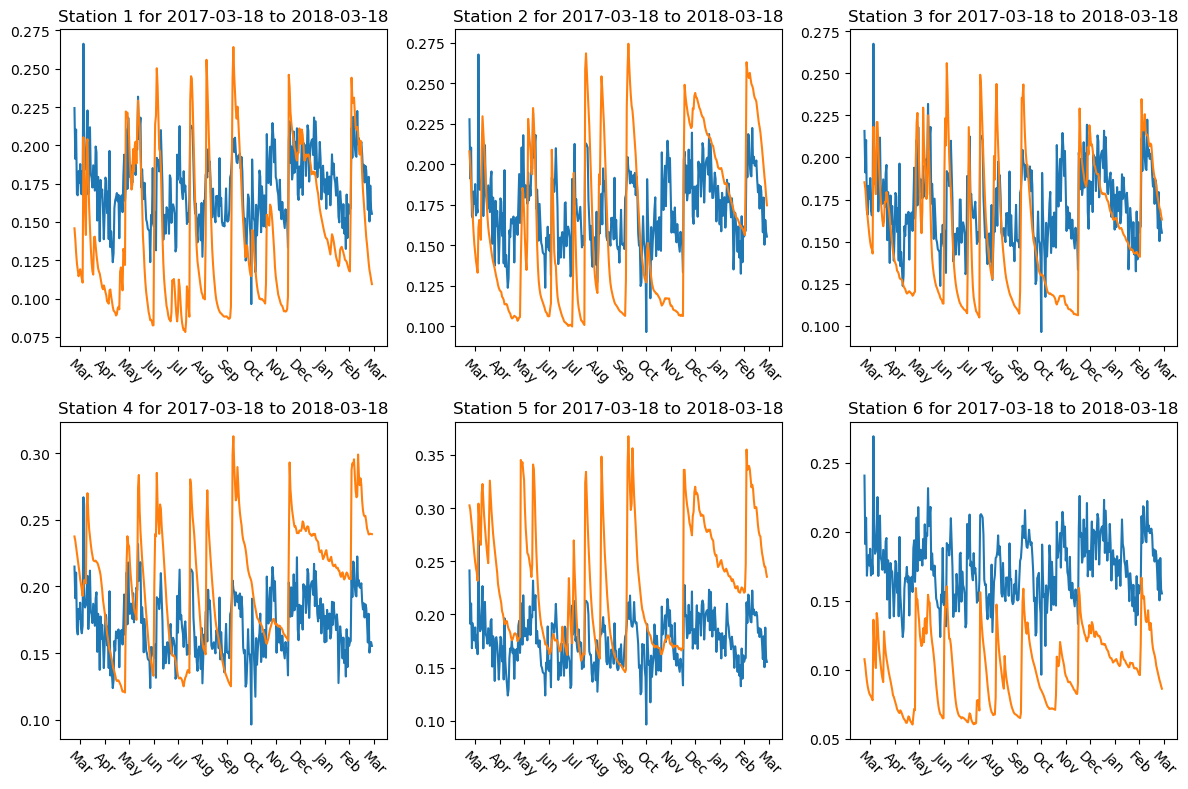

In [130]:
compare_data('2017-03-18', '2018-03-18')

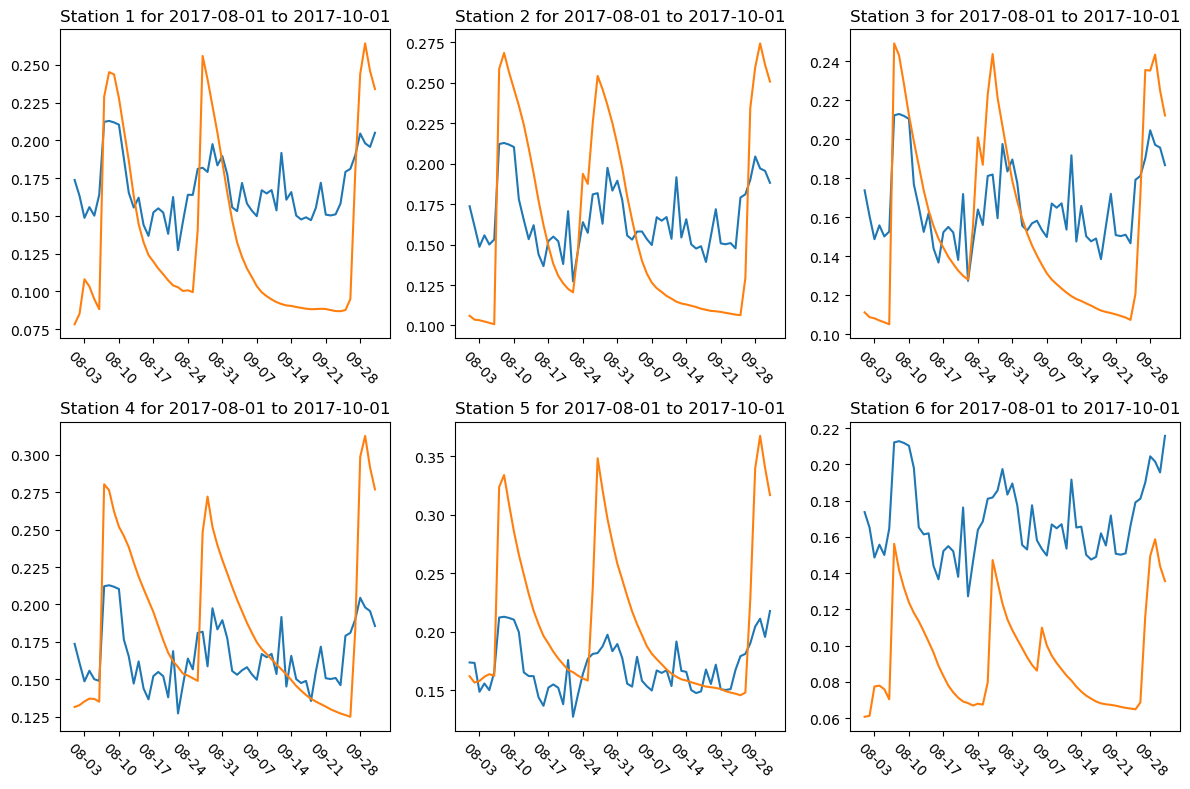

In [131]:
compare_data('2017-08-01', '2017-10-01', range_year=False)

### Interactive Plotly graphs for better visualization ###

In [165]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go

def plotly_graph(stat_id):
    start_date = sat_df_list[0].index[0]
    end_date = sm_stat_df_list[0].index[-1]
    sat_df = sat_df_list[stat_id - 1].loc[start_date:end_date]
    sm_stat_df = sm_stat_df_list[stat_id - 1].loc[start_date:end_date]

    fig = go.Figure()
    fig.add_scatter(x=sat_df.index, y=sat_df['soil_moisture'], mode='lines', name='Satellite data')
    fig.add_scatter(x=sm_stat_df.index, y=sm_stat_df['SWC_5'], mode='lines', name='Station data')
    fig.update_layout(
            title=f'Satellite data vs Station {stat_id} data',
            xaxis={'title': 'Date'},
            yaxis={'title': 'Soil Moisture'}
        )
    fig.show()

In [168]:
for i in range(1, 7):
    plotly_graph(i)